In [1]:
from __future__ import annotations

import operator
import os
import re
from datetime import date, datetime, timedelta
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from langchain_tavily import TavilySearch

In [2]:
# -----------------------------
# 1) Schemas
# -----------------------------
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=6,
        description="3–6 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(..., description="Target word count for this section (120–550).")

    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str

    # NEW: tells workers what genre this is (prevents drift)
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"

    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # prefer ISO "YYYY-MM-DD"
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    reason: str
    queries: List[str] = Field(default_factory=list)
    max_results_per_query: int = Field(5, description="How many results to fetch per query (3–8).")


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)

In [3]:
class State(TypedDict):
    topic: str

    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    # NEW: recency control
    as_of: str           # ISO date, e.g. "2026-01-29"
    recency_days: int    # 7 for weekly news, 30 for hybrid, etc.

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)
    final: str

In [4]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    
)

In [5]:
# -----------------------------
# 3) Router (decide upfront)
# -----------------------------
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- For open_book weekly roundup, include queries that reflect the last 7 days constraint.
"""

def router_node(state: State) -> dict:
    topic = state["topic"]
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}\nAs-of date: {state['as_of']}"),
        ]
    )

    # Set default recency window based on mode
    if decision.mode == "open_book":
        recency_days = 7
    elif decision.mode == "hybrid":
        recency_days = 45
    else:
        recency_days = 3650

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
        "recency_days": recency_days,
    }

def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"


In [6]:
# -----------------------------
# 4) Research (Tavily)
# -----------------------------
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    """
    Uses TavilySearchResults if installed and TAVILY_API_KEY is set.
    Returns list of dict with common fields. Note: published date is often missing.
    """
    tool = TavilySearch(max_results=max_results)    
    response = tool.invoke({"query": query})

    results = response.get("results", [])

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized


def _iso_to_date(s: Optional[str]) -> Optional[date]:
    if not s:
        return None
    try:
        return date.fromisoformat(s[:10])
    except Exception:
        return None


RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- Extract/normalize published_at as ISO (YYYY-MM-DD) if you can infer it from title/snippet.
  If you can't infer a date reliably, set published_at=null (do NOT guess).
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: State) -> dict:
    queries = (state.get("queries", []) or [])[:10]
    max_results = 6

    raw_results: List[dict] = []
    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(
                content=(
                    f"As-of date: {state['as_of']}\n"
                    f"Recency days: {state['recency_days']}\n\n"
                    f"Raw results:\n{raw_results}"
                )
            ),
        ]
    )

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e
    evidence = list(dedup.values())

    # HARD RECENCY FILTER for open_book weekly roundup:
    # keep only items with a parseable ISO date and within the window.
    mode = state.get("mode", "closed_book")
    if mode == "open_book":
        as_of = date.fromisoformat(state["as_of"])
        cutoff = as_of - timedelta(days=int(state["recency_days"]))
        fresh: List[EvidenceItem] = []
        for e in evidence:
            d = _iso_to_date(e.published_at)
            if d and d >= cutoff:
                fresh.append(e)
        evidence = fresh

    return {"evidence": evidence}

In [7]:
# -----------------------------
# 5) Orchestrator (Plan)
# -----------------------------
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5–9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3–6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120–550)

Flexibility:
- Do NOT use a fixed taxonomy unless it naturally fits.
- You may tag tasks (tags field), but tags are flexible.

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book (weekly news roundup):
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections (no scraping/RSS/how to fetch news) unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient fresh sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

def orchestrator_node(state: State) -> dict:
    planner = llm.with_structured_output(Plan)
    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    # Force blog_kind for open_book
    forced_kind = "news_roundup" if mode == "open_book" else None

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {state['as_of']} (recency_days={state['recency_days']})\n"
                    f"{'Force blog_kind=news_roundup' if forced_kind else ''}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:16]}\n\n"
                    f"Instruction: If mode=open_book, your plan must NOT drift into a tutorial."
                )
            ),
        ]
    )

    # Ensure open_book forces the kind even if model forgets
    if forced_kind:
        plan.blog_kind = "news_roundup"

    return {"plan": plan}


# -----------------------------
# 6) Fanout
# -----------------------------
def fanout(state: State):
    assert state["plan"] is not None
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "as_of": state["as_of"],
                "recency_days": state["recency_days"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].tasks
    ]

In [8]:
# -----------------------------
# 7) Worker (write one section)
# -----------------------------
WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order.
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown.
- Start with a '## <Section Title>' heading.
"""

def worker_node(payload: dict) -> dict:

    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])

    evidence = [
        EvidenceItem(**e)
        for e in payload.get("evidence", [])
    ]

    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")
    as_of = payload.get("as_of")
    recency_days = payload.get("recency_days")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}"
            for e in evidence[:20]
        )

    response = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {as_of} (recency_days={recency_days})\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n"
                    f"{evidence_text}\n"
                )
            ),
        ]
    )

    content = response.content

    if isinstance(content, str):
        section_md = content

    elif isinstance(content, list):
        parts = []

        for item in content:
            if isinstance(item, str):
                parts.append(item)

            elif isinstance(item, dict):
                if "text" in item:
                    parts.append(str(item["text"]))
                else:
                    parts.append(str(item))

            else:
                if hasattr(item, "text"):
                    parts.append(str(item.text))
                else:
                    parts.append(str(item))

        section_md = "\n".join(parts)

    else:
        section_md = str(content)

    
    
    section_md = section_md.replace("\\n", "\n").strip()

    return {
        "sections": [
            (task.id, section_md)
        ]
    }

In [9]:
from pathlib import Path
import re

def reducer_node(state):
    plan = state["plan"]

    ordered_sections = [
        md for _, md in sorted(
            state["sections"],
            key=lambda x: x[0]
        )
    ]

    body = "\n\n".join(ordered_sections)

    final_md = f"# {plan.blog_title}\n\n{body}"

    # Windows-invalid characters remove
    safe_title = re.sub(
        r'[<>:"/\\|?*]',
        "",
        plan.blog_title
    )

    filepath = Path("generated") / f"{safe_title}.md"

    filepath.write_text(
        final_md,
        encoding="utf-8"
    )

    print("SAVED TO:", filepath.resolve())

    return {"final": final_md}

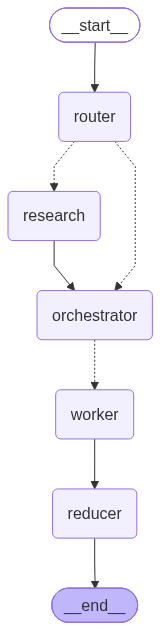

In [10]:
# -----------------------------
# 9) Build graph
# -----------------------------
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [11]:
# -----------------------------
# 10) Runner
# -----------------------------
def run(topic: str, as_of: Optional[str] = None):
    if as_of is None:
        as_of = date.today().isoformat()

    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "as_of": as_of,
            "recency_days": 7,   # router may overwrite
            "sections": [],
            "final": "",
        }
    )

    plan: Plan = out["plan"]
    print("\n" + "=" * 100)
    print("TOPIC:", topic)
    print("AS_OF:", out.get("as_of"), "RECENCY_DAYS:", out.get("recency_days"))
    print("MODE:", out.get("mode"))
    print("BLOG_KIND:", plan.blog_kind)
    print("NEEDS_RESEARCH:", out.get("needs_research"))
    print("QUERIES:", (out.get("queries") or [])[:6])
    print("EVIDENCE_COUNT:", len(out.get("evidence", [])))
    if out.get("evidence"):
        print("EVIDENCE_SAMPLE:", [e.model_dump() for e in out["evidence"][:2]])
    print("TASKS:", len(plan.tasks))
    print("SAVED_MD_CHARS:", len(out.get("final", "")))
    print("=" * 100 + "\n")


    return out

In [12]:
out = run("Write a blog on Self Love")

with open(
    f"{out['plan'].blog_title}.md",
    "r",
    encoding="utf-8"
) as f:
    print(f.read())

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


SAVED TO: C:\Users\pc\OneDrive\Desktop\Planning_Agent\generated\The Engineering of Self-Love A Systematic Approach to Personal Resilience and Burnout Prevention.md

TOPIC: Write a blog on Self Love
AS_OF: 2026-09-16 RECENCY_DAYS: 3650
MODE: closed_book
BLOG_KIND: explainer
NEEDS_RESEARCH: False
QUERIES: []
EVIDENCE_COUNT: 0
TASKS: 6
SAVED_MD_CHARS: 13445



FileNotFoundError: [Errno 2] No such file or directory: 'The Engineering of Self-Love: A Systematic Approach to Personal Resilience and Burnout Prevention.md'

In [ ]:
with open(
    f"{out['plan'].blog_title}.md",
    "r",
    encoding="utf-8"
) as f:
    print(f.read())
    

# The Engineering Mindset of Self-Love: Refactoring Your Internal Monologue

## Identifying the Legacy Code: Auditing Your Inner Critic

Every seasoned developer knows the dread of opening a massive, undocumented repository written years ago. It’s brittle, poorly commented, and prone to throwing errors under minimal load. Yet, many of us maintain an even worse legacy system daily: our inner critic. To practice self-love, you must first approach your internal monologue with the analytical rigor of a code audit. 

Start by cataloging your recurring negative automatic thoughts (NATs) in a dedicated journal or log. Treat these thoughts like raw telemetry data rather than absolute truths. When a self-deprecating thought fires off, write it down objectively without immediate patching. 

Next, categorize this destructive self-talk into severity levels ranging from minor deprecation warnings to critical system failures. A passing thought like "I could have optimized that loop better" is a mere